In [59]:
import vertexai
import pandas as pd
import os
import mimetypes
from IPython.display import Image, display
from vertexai.generative_models import GenerativeModel, ChatSession, HarmCategory, HarmBlockThreshold, Part
import json

In [60]:
PROJECT_ID = "spring-2026-lifejacket"
REGION = "us-central1"
vertexai.init(project=PROJECT_ID, location=REGION)

In [61]:
generation_config = {
    "temperature": 0.2,
    "top_p": 0.8,
    "top_k": 40,
    "max_output_tokens": 4096,
}

cv_model = GenerativeModel(
    "gemini-2.5-flash",
    generation_config=generation_config
)

Number of images found: 399
First 10 images: ['330933465.jpg', '341153933.jpg', '346684207.jpg', '335518879.jpg', '320945320.jpg', '262976150.jpg', '328221101.jpg', '286423259.jpg', '347620194.jpg', '315539579.jpg']
Selected image: 328858513.jpg
Image path: Gemini Confidence Testing/hurt_animal_dataset_images/328858513.jpg


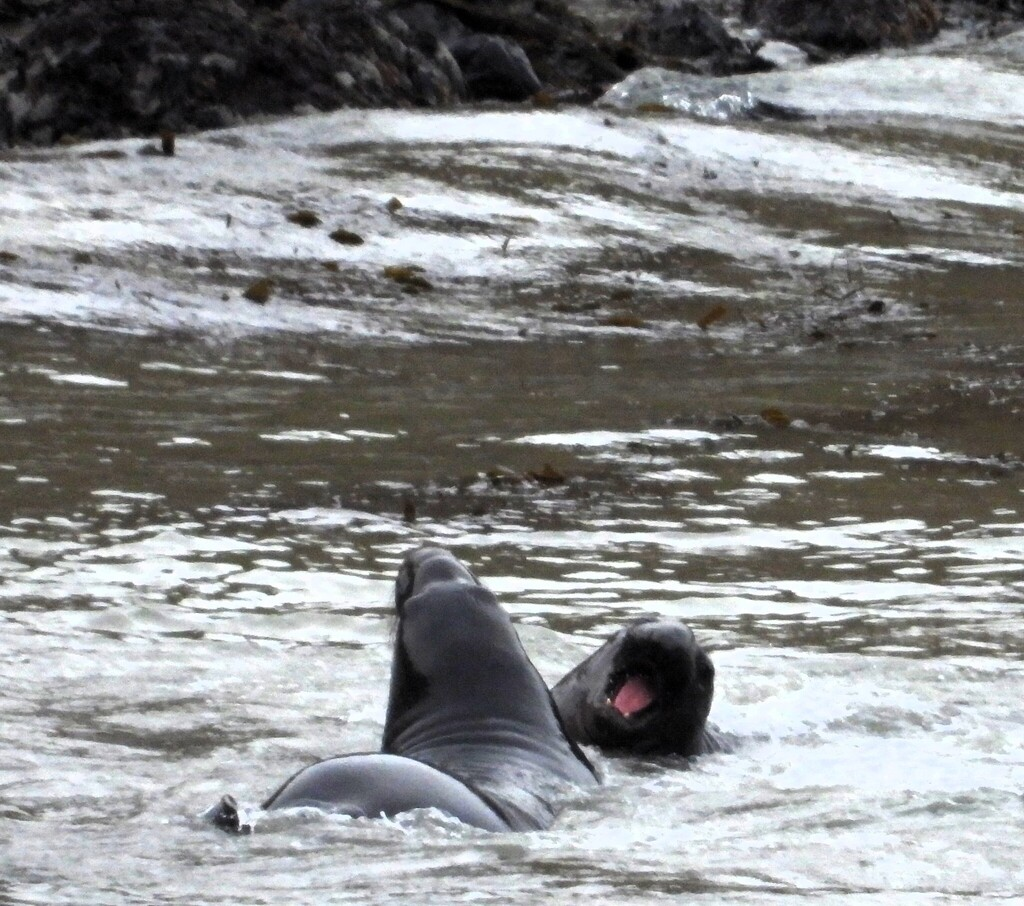

In [62]:
# real CV input from injury image folder

import os
from IPython.display import Image, display

IMAGE_FOLDER = "Gemini Confidence Testing/hurt_animal_dataset_images"

image_files = [
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
]

print("Number of images found:", len(image_files))
print("First 10 images:", image_files[:10])

IMAGE_INDEX = 30

image_filename = image_files[IMAGE_INDEX]
image_path = os.path.join(IMAGE_FOLDER, image_filename)

print("Selected image:", image_filename)
print("Image path:", image_path)

display(Image(filename=image_path, width=350))

In [63]:
def extract_json_from_text(text):
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```json", "", text)
        text = re.sub(r"^```", "", text)
        text = re.sub(r"```$", "", text)
        text = text.strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("No JSON object found in Gemini response.")

    return json.loads(text[start:end + 1])


def generate_cv_output_from_image(model, image_path):
    mime_type, _ = mimetypes.guess_type(image_path)
    if mime_type is None:
        mime_type = "image/jpeg"

    with open(image_path, "rb") as f:
        image_bytes = f.read()

    image_part = Part.from_data(
        data=image_bytes,
        mime_type=mime_type
    )

    prompt = """
You are a computer vision module for a marine wildlife rescue dispatch system.

Analyze the provided animal image and return ONLY valid JSON.

Your task:
1. Identify the top 3 most likely animal species or animal groups.
2. Give a confidence score for each candidate between 0 and 1.
3. Detect whether there may be a visible wound.
4. Detect whether visible blood appears in the image.
5. Determine whether the image is clear enough for species and injury assessment.
6. Briefly explain the image clarity reason.

Important rules:
- Return ONLY JSON.
- Do not include markdown.
- Do not include explanation outside JSON.
- Confidence scores should sum approximately to 1.
- The animal may be a marine mammal, sea turtle, bird, fish, shark, land mammal, domestic animal, or unknown wildlife.
- Do NOT assume the animal must be a marine mammal.
- If the animal has a visible shell or paddle-like limbs, strongly consider sea turtle.
- If the image is unclear, still provide best guesses but lower the confidence.
- Do not invent injury details that are not visible.
- If wound or blood cannot be determined, use false.
- If species cannot be determined, provide the best 3 guesses with low confidence.

Return JSON in exactly this structure:

{
  "cv_species_top3": [
    {
      "species": "species name or animal group",
      "confidence": 0.0
    },
    {
      "species": "species name or animal group",
      "confidence": 0.0
    },
    {
      "species": "species name or animal group",
      "confidence": 0.0
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "brief reason"
  }
}
"""

    response = model.generate_content([prompt, image_part])
    return extract_json_from_text(response.text)


cv_output = generate_cv_output_from_image(cv_model, image_path)

print("CV output generated from real image:")
print(json.dumps(cv_output, indent=2))

CV output generated from real image:
{
  "cv_species_top3": [
    {
      "species": "Elephant Seal",
      "confidence": 0.85
    },
    {
      "species": "Seal (general)",
      "confidence": 0.1
    },
    {
      "species": "Marine Mammal",
      "confidence": 0.05
    }
  ],
  "cv_observed_features": {
    "possible_wound": false,
    "visible_blood": false,
    "image_clear": true,
    "image_clarity_reason": "The animals are in focus and well-lit, allowing for clear observation of their features and general condition."
  }
}


# real location from dataset

raw_place_name = sample_row.get("description", "")

if pd.isna(raw_place_name):
    raw_place_name = ""

location_output = {
    "location_available": True,
    "location_source": "dataset_metadata.csv",
    "latitude": float(sample_row["latitude"]),
    "longitude": float(sample_row["longitude"]),
    "place_name": raw_place_name,
    "image_filename": image_filename,
    "image_date": str(sample_row.get("date", "")),
    "image_time": str(sample_row.get("time", ""))
}

print(json.dumps(location_output, indent=2))

In [64]:
# Mock location for testing
# Temporarily replace real dataset latitude / longitude with fixed mock values

location_output = {
    "location_available": False,
    "location_source": "mock_location_for_testing",
    "latitude": None,
    "longitude": None,
    "place_name": "Unknown test location",
    "image_filename": image_filename,
    "image_date": "",
    "image_time": ""
}

print("Mock location output:")
print(json.dumps(location_output, indent=2))

Mock location output:
{
  "location_available": false,
  "location_source": "mock_location_for_testing",
  "latitude": null,
  "longitude": null,
  "place_name": "Unknown test location",
  "image_filename": "328858513.jpg",
  "image_date": "",
  "image_time": ""
}


In [65]:
fixed_question_options = {
    "reported_size": {
        "question": "What is the animal's approximate body length?",
        "options": {
            "A": "very_small_under_1_ft",
            "B": "small_1_to_3_ft",
            "C": "medium_3_to_6_ft",
            "D": "large_6_to_10_ft",
            "E": "very_large_over_10_ft",
            "F": "not_sure"
        }
    },
    "reported_body_covering": {
        "question": "What does the animal's body covering look like?",
        "options": {
            "A": "fur_or_hair",
            "B": "feathers",
            "C": "scales_or_shell",
            "D": "smooth_skin",
            "E": "not_sure"
        }
    },
    "reported_mobility": {
        "question": "Is the animal moving?",
        "options": {
            "A": "moving_normally",
            "B": "moving_slowly_or_weakly",
            "C": "not_moving_but_appears_alive",
            "D": "not_moving_may_be_dead",
            "E": "not_sure"
        }
    },
    "reported_visible_wound": {
        "question": "Do you see any visible wound?",
        "options": {
            "A": True,
            "B": False,
            "C": "not_sure"
        }
    },
    "reported_entanglement_or_bleeding": {
        "question": "Do you see bleeding or anything tangled around the animal?",
        "options": {
            "A": "bleeding",
            "B": "tangled_in_line_net_rope_or_plastic",
            "C": "both_bleeding_and_tangled",
            "D": "neither",
            "E": "not_sure"
        }
    }
}

In [66]:
def ask_fixed_questions():
    user_answers = {}

    for field_name, q in fixed_question_options.items():
        print("\n" + q["question"])
        for key, value in q["options"].items():
            print(f"{key}. {value}")

        user_choice = input("Choose one option: ").strip().upper()

        while user_choice not in q["options"]:
            print("Invalid choice. Please choose again.")
            user_choice = input("Choose one option: ").strip().upper()

        user_answers[field_name] = q["options"][user_choice]

    return user_answers


user_fixed_answers = ask_fixed_questions()

print(user_fixed_answers)


What is the animal's approximate body length?
A. very_small_under_1_ft
B. small_1_to_3_ft
C. medium_3_to_6_ft
D. large_6_to_10_ft
E. very_large_over_10_ft
F. not_sure


Choose one option:  C



What does the animal's body covering look like?
A. fur_or_hair
B. feathers
C. scales_or_shell
D. smooth_skin
E. not_sure


Choose one option:  A



Is the animal moving?
A. moving_normally
B. moving_slowly_or_weakly
C. not_moving_but_appears_alive
D. not_moving_may_be_dead
E. not_sure


...


Do you see any visible wound?
A. True
B. False
C. not_sure


Choose one option:  B



Do you see bleeding or anything tangled around the animal?
A. bleeding
B. tangled_in_line_net_rope_or_plastic
C. both_bleeding_and_tangled
D. neither
E. not_sure


Choose one option:  A


{'reported_size': 'medium_3_to_6_ft', 'reported_body_covering': 'fur_or_hair', 'reported_mobility': 'moving_normally', 'reported_visible_wound': False, 'reported_entanglement_or_bleeding': 'bleeding'}


In [71]:
# Integrate three separate inputs into one structured package for Gemini

incident_package = {

    "cv_output": cv_output,

    "location_output": location_output,

    "user_fixed_answers": user_fixed_answers

}

print(json.dumps(incident_package, indent=2))

{
  "cv_output": {
    "cv_species_top3": [
      {
        "species": "Elephant Seal",
        "confidence": 0.85
      },
      {
        "species": "Seal (general)",
        "confidence": 0.1
      },
      {
        "species": "Marine Mammal",
        "confidence": 0.05
      }
    ],
    "cv_observed_features": {
      "possible_wound": false,
      "visible_blood": false,
      "image_clear": true,
      "image_clarity_reason": "The animals are in focus and well-lit, allowing for clear observation of their features and general condition."
    }
  },
  "location_output": {
    "location_available": false,
    "location_source": "mock_location_for_testing",
    "latitude": null,
    "longitude": null,
    "place_name": "Unknown test location",
    "image_filename": "328858513.jpg",
    "image_date": "",
    "image_time": ""
  },
  "user_fixed_answers": {
    "reported_size": "medium_3_to_6_ft",
    "reported_body_covering": "fur_or_hair",
    "reported_mobility": "moving_normally",

## LLM

In [72]:
def build_llm_prompt(incident_package, followup_history=None):
    if followup_history is None:
        followup_history = []

    prompt = f"""
You are Agent 1: Wildlife Incident Intake and Verification Agent.

You receive one structured input package called incident_package.
This package contains three separate inputs:
1. cv_output from a teammate's computer vision module
2. location_output from a mocked location service
3. user_fixed_answers from fixed multiple-choice intake questions

Important:
- The CV module has already analyzed the photo.
- Do not claim that you directly inspected the image.
- Use only cv_output, location_output, user_fixed_answers, and followup_history.

- Your first task is to combine all evidence in the incident_package and followup_history.
- Before deciding whether a follow-up is needed, create your own updated species estimate and updated confidence score.
- The updated confidence score must be based on the combined evidence from:
  1. cv_output
  2. user_fixed_answers
  3. location_output
  4. followup_history
- Do not simply copy the CV confidence score as llm_species_confidence.
- Treat the CV confidence score as one evidence signal.
- Treat user_fixed_answers as another evidence signal.
- If user_fixed_answers provide strong visual evidence, such as body covering, mobility, wound status, bleeding, or entanglement, use those answers to adjust the confidence score.
- If the CV result and user_fixed_answers point to different animal groups, record this in llm_followup_reason and lower confidence unless the combined evidence strongly supports one candidate.
- After calculating the updated llm_species_confidence, apply the follow-up logic:
  - If llm_species_confidence is 0.90 or above, set species_verification_status to "verified" and llm_needs_followup to false.
  - If llm_species_confidence is below 0.90, ask exactly one targeted follow-up question unless stop_uncertain or request_new_photo is more appropriate.

- Ask no more than 5 quesitons.
- Injury confidence does not need to be above 0.90. If injury information is uncertain, record it as unknown or low confidence.
- Always give safe public guidance.
- Do not tell the reporter to touch, feed, move, pour water on, or approach the animal.

Follow-up policy:
Choose exactly one llm_followup_type when follow-up is needed:
1. "species_disambiguation" if the animal group or species needs clarification, such as mammal vs bird, seal vs sea lion, dolphin vs seal, turtle vs bird, or domestic animal vs wildlife.
2. "cv_user_conflict" if CV output and user answers conflict.
3. "request_new_photo" if the image or current evidence is too unclear and another photo would help.
4. "injury_clarification" if injury risk needs clarification, such as bleeding, wound, or entanglement.
5. "stop_uncertain" if enough follow-up has already been attempted but confidence is still below 0.90.

Follow-up question rules:
- Ask exactly one follow-up question at a time.
- Each follow-up question must ask only one thing.
- Do not combine multiple traits in one question.
- Do not ask the same or semantically similar follow-up question twice.
- If a follow-up question has already been answered in followup_history, use that answer to update your confidence.
- If the answer is unclear, ask a different question or request a new photo.
- Do not keep asking follow-up questions indefinitely.

Species disambiguation rules:
- Start from cv_species_top3 as the initial visual candidates.
- Then update the likely animal group, likely species, and confidence using user_fixed_answers, location_output, and followup_history.
- The final llm_likely_species and llm_species_confidence should represent the combined evidence, not the raw CV result alone.
- If user_fixed_answers strongly suggest a different animal group than cv_species_top3, include that conflict in cv_user_agreement_status and llm_followup_reason.
- If the combined evidence supports a candidate that is not the top CV candidate, choose the better-supported candidate.

Animal group vs species verification:
- Use animal group as an intermediate reasoning step, not as the final verification threshold.
- The 0.90 threshold applies to llm_species_confidence.
- If llm_species_confidence is below 0.90, decide the follow-up question based on where uncertainty exists.
- If the broad animal group is uncertain, ask a group-level follow-up question first.
- If the broad animal group is clear but the exact species is uncertain, ask a species-level follow-up question.
- Do not mark species_verification_status as "verified" based only on animal group confidence.
- First identify the broad animal group when possible:
  1. marine mammal, such as seal, sea lion, dolphin, whale, otter
  2. sea turtle or reptile
  3. bird, such as duck, gull, pelican
  4. land mammal, such as dog, wolf, coyote, deer
  5. fish or shark
  6. unknown animal

- When species confidence is below 0.90, choose exactly one follow-up question that best separates the most likely candidate species.
- The question should focus on one visible or behavioral trait only.
- Prefer broad, easy-to-answer traits before asking highly specific species traits.
- Do not ask questions that require expert biological knowledge.
- Do not ask the user to approach, touch, move, or disturb the animal.

General disambiguation traits:
- Body covering:
  Use this when distinguishing mammal vs bird vs reptile vs fish.
  Example question: "Does the animal appear to have fur, feathers, scales, or a smooth body?"

- Main body shape:
  Use this when distinguishing seal/sea lion/dolphin/turtle/bird/land mammal.
  Example question: "Is the animal's body long and torpedo-shaped, round and compact, shell-covered, or bird-shaped?"

- Limbs or movement parts:
  Use this when distinguishing flippers, fins, wings, legs, or shell-based movement.
  Example question: "What type of limbs are most visible: flippers, fins, wings, legs, or a shell with paddle-like limbs?"

- Head or face feature:
  Use this when distinguishing bird vs mammal vs turtle, or similar-looking mammals.
  Example question: "Does the animal have a beak, a snout, or a rounded head without a beak?"

- Water-adapted features:
  Use this when distinguishing dolphin/whale from seal/sea lion.
  Example question: "Can you see a dorsal fin on the animal's back?"

- Shell feature:
  Use this when sea turtle is a candidate.
  Example question: "Can you see a hard shell covering most of the animal's back?"

- Bird feature:
  Use this when duck, gull, pelican, or another bird is a candidate.
  Example question: "Can you see feathers on the animal?"

- Seal vs sea lion feature:
  Use this only when the top candidate species are pinnipeds, such as seal, sea lion, or fur seal.
  Do not treat visible ear flaps as California sea lion only, because fur seals may also have external ear flaps.
  External ear flaps support the broader group of eared seals, including sea lions and fur seals, over true seals.
  Lack of external ear flaps supports true seals over eared seals.
  Example question: "Can you see small external ear flaps, or only tiny ear holes?"

- Movement pattern:
  Use this only when the user already observed movement from a safe distance.
  Do not ask the user to make the animal move.
  If the animal uses front flippers and can lift its chest, this supports eared seals such as sea lions or fur seals.
  If the animal crawls on its belly without lifting the body much, this supports true seals.
  Example question: "From what you already observed, did it lift its chest and use front flippers, or mostly crawl on its belly?"

- Location consistency:
  Use location_output only as supporting evidence, not as the only deciding factor.
  If the species predicted by CV is unlikely for the location, lower confidence and consider requesting clarification or a new photo.
  Do not reject a species only because it is unusual for the location.

- If the follow-up answer clearly supports one candidate group, update llm_likely_species and adjust confidence.
- If the follow-up answer contradicts the CV top species, lower confidence for that species and consider another candidate from cv_species_top3.
- If the follow-up answer is unclear or does not separate the candidates, request a new photo from a safe distance.
- Do not artificially raise confidence to 0.90 unless the evidence clearly supports verification.

CV-user conflict rules:
- If CV output and user_fixed_answers conflict, set llm_followup_type to "cv_user_conflict" when clarification would materially improve confidence.
- Do not overwrite user answers. Record the conflict in llm_followup_reason or llm_injury_summary.
- If user_fixed_answers report bleeding as true but cv_visible_blood is false, set llm_bleeding_present based on the combined evidence and mention the discrepancy.
- If user_fixed_answers report visible wound as true, set llm_wound_present to true unless follow-up evidence clearly contradicts it.

Image quality / new photo rules:
- If evidence remains insufficient after one species_disambiguation question, prefer llm_followup_type = "request_new_photo".
- When requesting a new photo, ask the user to upload another photo from a safe distance without approaching the animal.
- If requesting a new photo, set new_photo_requested to true and species_verification_status to "new_photo_requested".

Stop uncertain rules:
- If followup_history already contains 2 or more entries and species confidence is still below 0.90, do not ask more questions.
- Set llm_needs_followup to false.
- Set llm_followup_type to "stop_uncertain".
- Set species_verification_status to "uncertain_needs_review".
- Keep the best current species estimate and confidence.
- Do not artificially raise confidence to 0.90 if the evidence is insufficient.

Allowed species_verification_status values:
- "verified"
- "needs_followup"
- "new_photo_requested"
- "uncertain_needs_review"

Follow-up history:
{json.dumps(followup_history, indent=2)}

Input incident_package:
{json.dumps(incident_package, indent=2)}

Return JSON only. Do not include markdown.

Required JSON schema:
{{
  "llm_likely_animal_group": "",
  "llm_animal_group_confidence": 0.0,
  "llm_likely_species": "",
  "llm_species_confidence": 0.0,
  "confidence_evidence_summary": "",
  "cv_user_agreement_status": "",
  "species_verification_status": "",
  "llm_needs_followup": true,
  "llm_followup_type": "",
  "llm_followup_reason": "",
  "llm_followup_question": "",
  "new_photo_requested": false,

  "llm_injury_present": false,
  "llm_injury_confidence": 0.0,
  "llm_wound_present": false,
  "llm_bleeding_present": false,
  "llm_entanglement_present": false,
  "llm_swelling_present": false,
  "llm_abnormal_posture_present": false,
  "llm_respiratory_distress_present": false,
  "llm_unresponsive_present": false,
  "llm_mobility_concern": "",
  "llm_injury_summary": "",

  "guidance_message": ""
}}
"""
    return prompt

In [73]:
def extract_json_from_response(text):
    text = text.strip()

    if text.startswith("```json"):
        text = text.replace("```json", "", 1).strip()
    if text.startswith("```"):
        text = text.replace("```", "", 1).strip()
    if text.endswith("```"):
        text = text[:-3].strip()

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        raise ValueError("No JSON object found in Gemini response.")

    json_text = text[start:end + 1]

    try:
        return json.loads(json_text)
    except json.JSONDecodeError as e:
        print("\nJSON parsing failed.")
        print(f"Error: {e}")
        print("\nProblematic JSON text:")
        print(json_text)
        raise


def call_gemini_for_assessment(model, incident_package, followup_history=None):
    prompt = build_llm_prompt(incident_package, followup_history)

    print("\nSending incident package to Gemini...")

    response = model.generate_content(prompt)

    response_text = response.text
    llm_output = extract_json_from_response(response_text)

    return llm_output

**If species confidence < 90%，Start chatbox follow-up**

In [74]:
def run_species_followup_chat(model, incident_package, max_followups=3):
    followup_history = []
    new_photo_requested_once = False
    last_llm_output = None

    for i in range(max_followups + 2):

        question_followups = [
            item for item in followup_history
            if item.get("followup_type") != "request_new_photo"
        ]

        if len(question_followups) >= max_followups:
            print("\nMax follow-up question limit reached. Stop without another Gemini call.")

            if last_llm_output is not None:
                last_llm_output["llm_needs_followup"] = False
                last_llm_output["llm_followup_type"] = "stop_uncertain"
                last_llm_output["species_verification_status"] = "uncertain_needs_review"
                return last_llm_output, followup_history

        print(f"\nLLM assessment round {i + 1}")

        llm_output = call_gemini_for_assessment(
            model=model,
            incident_package=incident_package,
            followup_history=followup_history
        )

        last_llm_output = llm_output

        species_confidence = llm_output.get("llm_species_confidence", 0.0)
        likely_species = llm_output.get("llm_likely_species", "")
        needs_followup = llm_output.get("llm_needs_followup", False)
        followup_type = llm_output.get("llm_followup_type", "")
        followup_question = llm_output.get("llm_followup_question", "")
        verification_status = llm_output.get("species_verification_status", "")

        cv_features = incident_package.get("cv_output", {}).get("cv_observed_features", {})
        image_clear = cv_features.get("image_clear", True)
        image_clarity_reason = cv_features.get("image_clarity_reason", "")

        print(f"Likely species: {likely_species}")
        print(f"Species confidence: {species_confidence}")
        print(f"Species verification status: {verification_status}")
        print(f"Follow-up type: {followup_type}")
        print(f"Image clear: {image_clear}")
        print(f"Image clarity reason: {image_clarity_reason}")
        print(f"Injury present: {llm_output.get('llm_injury_present')}")
        print(f"Injury summary: {llm_output.get('llm_injury_summary')}")
        print(f"Guidance: {llm_output.get('guidance_message')}")

        if species_confidence >= 0.90:
            print("\nSpecies confidence is above 90%. Stop follow-up.")
            return llm_output, followup_history

        if followup_type == "stop_uncertain":
            print("\nSpecies is still uncertain. Stop follow-up and mark for review.")
            return llm_output, followup_history

        if not needs_followup:
            print("\nNo follow-up needed. Stop follow-up.")
            return llm_output, followup_history

        print("\nFollow-up question:")
        print(followup_question)

        user_answer = input("Your answer: ").strip()

        followup_history.append({
            "followup_type": followup_type,
            "question": followup_question,
            "answer": user_answer
        })

    return last_llm_output, followup_history

In [75]:
generation_config = {
    "temperature": 0.2,
    "top_p": 0.8,
    "top_k": 40,
    "max_output_tokens": 4096,
}

model = GenerativeModel(
    "gemini-2.5-flash",
    generation_config=generation_config
)

final_llm_output, followup_history = run_species_followup_chat(
    model=model,
    incident_package=incident_package,
    max_followups=2
)

print("\nFinal LLM output:")
print(json.dumps(final_llm_output, indent=2))

print("\nFollow-up history:")
print(json.dumps(followup_history, indent=2))


LLM assessment round 1

Sending incident package to Gemini...


ValueError: No JSON object found in Gemini response.

**CSV output**

In [39]:
import pandas as pd
import uuid
from datetime import datetime

In [42]:
def build_database_row(incident_package, final_llm_output, followup_history):
    cv_output = incident_package["cv_output"]
    location_output = incident_package["location_output"]
    user_answers = incident_package["user_fixed_answers"]

    cv_species_top3 = cv_output.get("cv_species_top3", [])
    cv_features = cv_output.get("cv_observed_features", {})

    def get_species_field(index, field):
        if len(cv_species_top3) > index:
            return cv_species_top3[index].get(field)
        return None

    row = {
        "incident_id": f"INC_{uuid.uuid4().hex[:8]}",
        "photo_id": location_output.get("image_filename", f"PHOTO_{uuid.uuid4().hex[:8]}"),
        "animal_id": f"ANIMAL_{uuid.uuid4().hex[:8]}",
        "report_timestamp": datetime.now().isoformat(timespec="seconds"),

        # real image metadata
        "image_filename": location_output.get("image_filename"),
        "image_date": location_output.get("image_date"),
        "image_time": location_output.get("image_time"),

        # real location metadata
        "latitude": location_output.get("latitude"),
        "longitude": location_output.get("longitude"),
        "place_name": location_output.get("place_name"),
        "location_source": location_output.get("location_source"),

        # CV species output
        "cv_top1_species": get_species_field(0, "species"),
        "cv_top1_confidence": get_species_field(0, "confidence"),
        "cv_top2_species": get_species_field(1, "species"),
        "cv_top2_confidence": get_species_field(1, "confidence"),
        "cv_top3_species": get_species_field(2, "species"),
        "cv_top3_confidence": get_species_field(2, "confidence"),

        # CV observed features
        "cv_possible_wound": cv_features.get("possible_wound"),
        "cv_visible_blood": cv_features.get("visible_blood"),
        "cv_image_clear": cv_features.get("image_clear"),
        "cv_image_clarity_reason": cv_features.get("image_clarity_reason"),

        # user fixed answers
        "reported_size": user_answers.get("reported_size"),
        "reported_color": user_answers.get("reported_color"),
        "reported_mobility": user_answers.get("reported_mobility"),
        "reported_visible_wound": user_answers.get("reported_visible_wound"),
        "reported_bleeding": user_answers.get("reported_bleeding"),

        # LLM species verification output
        "llm_likely_species": final_llm_output.get("llm_likely_species"),
        "llm_species_confidence": final_llm_output.get("llm_species_confidence"),
        "species_verification_status": final_llm_output.get("species_verification_status"),
        "llm_needs_followup": final_llm_output.get("llm_needs_followup"),
        "llm_followup_type": final_llm_output.get("llm_followup_type"),
        "llm_followup_reason": final_llm_output.get("llm_followup_reason"),
        "llm_followup_question": final_llm_output.get("llm_followup_question"),
        "new_photo_requested": final_llm_output.get("new_photo_requested"),

        # LLM injury output
        "llm_injury_present": final_llm_output.get("llm_injury_present"),
        "llm_injury_confidence": final_llm_output.get("llm_injury_confidence"),
        "llm_wound_present": final_llm_output.get("llm_wound_present"),
        "llm_bleeding_present": final_llm_output.get("llm_bleeding_present"),
        "llm_entanglement_present": final_llm_output.get("llm_entanglement_present"),
        "llm_swelling_present": final_llm_output.get("llm_swelling_present"),
        "llm_abnormal_posture_present": final_llm_output.get("llm_abnormal_posture_present"),
        "llm_respiratory_distress_present": final_llm_output.get("llm_respiratory_distress_present"),
        "llm_unresponsive_present": final_llm_output.get("llm_unresponsive_present"),
        "llm_mobility_concern": final_llm_output.get("llm_mobility_concern"),
        "llm_injury_summary": final_llm_output.get("llm_injury_summary"),

        # public guidance
        "guidance_message": final_llm_output.get("guidance_message"),

        # full traceability
        "followup_count": len(followup_history),
        "followup_history_json": json.dumps(followup_history, ensure_ascii=False),
        "incident_package_json": json.dumps(incident_package, ensure_ascii=False, default=str),
        "final_llm_output_json": json.dumps(final_llm_output, ensure_ascii=False)
    }

    return row

In [43]:
def save_database_row_to_csv(database_row, csv_path="agent1_incident_database.csv"):
    new_df = pd.DataFrame([database_row])

    try:
        existing_df = pd.read_csv(csv_path)
        final_df = pd.concat([existing_df, new_df], ignore_index=True)
    except FileNotFoundError:
        final_df = new_df

    final_df.to_csv(csv_path, index=False)
    return final_df

In [44]:
database_row = build_database_row(
    incident_package=incident_package,
    final_llm_output=final_llm_output,
    followup_history=followup_history
)

database_df = save_database_row_to_csv(
    database_row=database_row,
    csv_path="agent1_incident_database.csv"
)

print("\nSaved one incident row to CSV.")
print(database_df.tail(1))


Saved one incident row to CSV.
    incident_id        photo_id        animal_id     report_timestamp  \
0  INC_b0fe9663  PHOTO_7beeb559  ANIMAL_a684d074  2026-05-11T22:36:40   

   latitude  longitude               place_name location_source  \
0   34.4208  -119.6982  Santa Barbara Beach, CA   mock_location   

       cv_top1_species  cv_top1_confidence  ... llm_abnormal_posture_present  \
0  California sea lion                0.72  ...                        False   

   llm_respiratory_distress_present llm_unresponsive_present  \
0                             False                    False   

   llm_mobility_concern                                 llm_injury_summary  \
0                  none  A wound is reported by both computer vision an...   

                                    guidance_message followup_count  \
0  Thank you for reporting this incident at Santa...              1   

                               followup_history_json  \
0  [{"question": "Does the animal have v